# Generate Weak Labels for ML Classification using Heuristics

In [1]:
from src.find_bids.models.extract.series import SeriesFeatures, initialize_features_db
from src.find_bids.models.extract.dataset import Dataset
# from src.find_bids.models.infer.datatype import 
from src.find_bids.models.infer.core import DatasetsInference
from src.find_bids.models.infer.utils import collect_tokens
from src.find_bids.models.infer.datatype import score_datatype, score_anat, score_func, score_dwi, score_fmap, score_perf
from src.find_bids.models.infer.suffix import score_suffix

from pathlib import Path

import pandas as pd
from upath import UPath
import seaborn as sns
import matplotlib.pyplot as plt
from rich.progress import track

In [2]:
DB_PATH = UPath("/Volumes/csi/Quarles_Lab/find_BIDS/features/features.db")
# conn = initialize_features_db(DB_PATH)

In [3]:
# # Currently, the originally generated features are not available, so we are generating them again into a temp folder
# root_dir = UPath("ssh://seadragon/rsrch5/home/csi/Quarles_Lab/")
# # root_dir = UPath("/Volumes/csi/Quarles_Lab/")
# proactive_dataset_features_path = root_dir / "find_BIDS/features/PROACTIVE/dataset.json"
# qiac_dataset_features_path = root_dir / "find_BIDS/features/QIAC/dataset.json"

# if proactive_dataset_features_path.exists():
#     proactive_dataset = Dataset.from_json(proactive_dataset_features_path)
#     # proactive_dataset.rebuild_paths_with_new_root(old_root=UPath("/rsrch5/home/csi/Quarles_Lab/"), new_root=UPath("/Volumes/csi/Quarles_Lab/"))
#     proactive_dataset.rebuild_paths_with_new_root(old_root=UPath("/rsrch5/home/"), new_root=UPath("ssh://seadragon/rsrch5/home"))
#     proactive_dataset.dir_root = root_dir / proactive_dataset.dir_root.relative_to(UPath("/rsrch5/home/csi/Quarles_Lab/"))
# else:
#     raise FileNotFoundError(f"Proactive dataset features not found at {proactive_dataset_features_path}")

# if qiac_dataset_features_path.exists():
#     qiac_dataset = Dataset.from_json(qiac_dataset_features_path)
#     # qiac_dataset.rebuild_paths_with_new_root(old_root=UPath("/rsrch5/home/csi/Quarles_Lab/"), new_root=UPath("/Volumes/csi/Quarles_Lab/"))
#     qiac_dataset.rebuild_paths_with_new_root(old_root=UPath("/rsrch5/home/"), new_root=UPath("ssh://seadragon/rsrch5/home"))
#     # qiac_dataset.features_root = UPath("ssh://seadragon" + str(qiac_dataset.features_root))
#     qiac_dataset.dir_root = root_dir / qiac_dataset.dir_root.relative_to(UPath("/rsrch5/home/csi/Quarles_Lab/"))
# else:
#     raise FileNotFoundError(f"QIAC dataset features not found at {qiac_dataset_features_path}")
#     # print(f"QIAC dataset features not found at {qiac_dataset_features_path}, proceeding without QIAC dataset")

In [4]:
root_dir = UPath("/Volumes/csi/Quarles_Lab/")
proactive_dataset_features_path = root_dir / "find_BIDS/features/PROACTIVE/dataset.json"
qiac_dataset_features_path = root_dir / "find_BIDS/features/QIAC/dataset.json"

if proactive_dataset_features_path.exists():
    proactive_dataset = Dataset.from_json(proactive_dataset_features_path)
    # proactive_dataset.rebuild_paths_with_new_root(old_root=UPath("/rsrch5/home/"), new_root=UPath("/Volumes/"))
    # proactive_dataset.dir_root = root_dir / proactive_dataset.dir_root.relative_to(UPath("/rsrch5/home/csi/Quarles_Lab/"))
else:
    raise FileNotFoundError(f"Proactive dataset features not found at {proactive_dataset_features_path}")

if qiac_dataset_features_path.exists():
    qiac_dataset = Dataset.from_json(qiac_dataset_features_path)
    # qiac_dataset.rebuild_paths_with_new_root(old_root=UPath("/rsrch5/home/csi/Quarles_Lab/"), new_root=UPath("/Volumes/csi/Quarles_Lab/"))
    # qiac_dataset.rebuild_paths_with_new_root(old_root=UPath("/rsrch5/home/"), new_root=UPath("/Volumes/"))
    # qiac_dataset.features_root = UPath("ssh://seadragon" + str(qiac_dataset.features_root))
    # qiac_dataset.dir_root = root_dir / qiac_dataset.dir_root.relative_to(UPath("/rsrch5/home/csi/Quarles_Lab/"))
else:
    raise FileNotFoundError(f"QIAC dataset features not found at {qiac_dataset_features_path}")

In [5]:
first_subject_id: str = list(proactive_dataset.subjects.keys())[0]
first_session_id: str = list(proactive_dataset.subjects[first_subject_id].sessions.keys())[0]
# proactive_dataset.dir_root, proactive_dataset.features_root, proactive_dataset.subjects[first_subject_id].sessions[first_session_id].path
# proactive_dataset.rebuild_paths_with_new_root(old_root=UPath("/rsrch5/home/"), new_root=UPath("/Volumes/"))
proactive_dataset.dir_root, proactive_dataset.features_root, proactive_dataset.subjects[first_subject_id].sessions[first_session_id].data_path

(PosixUPath('/Volumes/NeuroCare/PROACTIVE/xnat'),
 PosixUPath('/Volumes/csi/Quarles_Lab/find_BIDS/features/PROACTIVE'),
 PosixUPath('/Volumes/NeuroCare/PROACTIVE/xnat/2379-7808/2379-7808-3494-5344'))

In [6]:
series_features = SeriesFeatures.from_dicom_series(UPath("/Volumes/csi/Quarles_Lab/Bajaj_Projects/Melanoma_Data_QIAC/Raw_MRI/1014-1361-3674-3763/SCANS/13 - +C Ax 3D T1 XRT/DICOM"))
print(series_features)

Series Features
---------------
  Series UID: 1.3.12.2.1107.5.2.18.52115.30000025072916595034600000069
  Study UID: 1.2.840.114350.2.412.2.798268.2.559546015.1
  Modality: mr (consistency=1.0)
  Number of instances: 224
  Unique slices: 224
  Volumes: 1
  Manufacturer: siemens healthineers (consistency=1.0)
  Model: magnetom aera (consistency=1.0)
  Field strength: 1.5 (iqr=0.0, valid_fraction=1.0, stable=True)
  Series number: 13.0 (iqr=0.0, valid_fraction=1.0, stable=True)
  Geometry:
    Geometry Features
    -----------------
      Rows: 256.0 (iqr=0.0, valid_fraction=1.0, stable=True)
      Columns: 256.0 (iqr=0.0, valid_fraction=1.0, stable=True)
      Number of slices: 224
      Voxel size (mm): (1.0, 1.0, 1.0)
      Matrix size (voxels): (256, 256, 224)
      Geometry hash: 66cd9bd51e43585374caa74acb396439
  Temporal:
    Temporal Features
    -----------------
      Repetition time: 10.0 (iqr=0.0, valid_fraction=1.0, stable=True)
      Echo time: 4.76 (iqr=0.0, valid_fraction=

In [7]:
data_inference_sample = DatasetsInference.from_datasets(
    datasets=[proactive_dataset, qiac_dataset],
    sample_subjects_per_subjects=2,
    # conn=conn
    )
data_inference_sample.to_csv("sample_heuristic_scores.csv")
data_inference_sample.to_dataframe().head()

Output()

KeyboardInterrupt: 

In [ ]:
# len(proactive_dataset.subjects)
# Find what subjects were not processed
subjects_without_sessions = []
sessions_without_series = []
series_without_features = []

for subject_id, subject in track(proactive_dataset.subjects.items(), description="Checking for missing features", total=len(proactive_dataset.subjects)):
    if not subject.sessions:
        subjects_without_sessions.append(subject_id)
        continue
    for session_id, session in subject.sessions.items():
        if not session.series:
            sessions_without_series.append((subject_id, session_id))
            continue
        for series_id, series in session.series.items():
            features_path = proactive_dataset.features_root / subject_id / session_id / f"{series_id}.json"
            if not features_path.exists():
                series_without_features.append(series.data_path)
                
# Write out the missing features to a log file
missing_features_log_path = "proactive_missing_features.log"
with open(missing_features_log_path, "w") as log_file:
    if subjects_without_sessions:
        log_file.write(f"Subjects without sessions ({len(subjects_without_sessions)}):\n")
        for subject_id in subjects_without_sessions:
            log_file.write(f"  - {subject_id}\n")
    else:
        log_file.write("All subjects have sessions.\n")
    
    if sessions_without_series:
        log_file.write(f"\nSessions without series ({len(sessions_without_series)}):\n")
        for subject_id, session_id in sessions_without_series:
            log_file.write(f"  - Subject: {subject_id}, Session: {session_id}\n")
    else:
        log_file.write("\nAll sessions have series.\n")
    
    if series_without_features:
        log_file.write(f"\nSeries without extracted features ({len(series_without_features)}):\n")
        for series_path in series_without_features:
            log_file.write(f"  - Series path: {series_path}\n")
    else:
        log_file.write("\nAll series have extracted features.\n")

Output()

In [ ]:
series_features = SeriesFeatures.from_dicom_series("/Volumes/csi/Quarles_Lab/PROACTIVE_De-identidied/2190-0092/2190-0092-2339-6221/3/DICOM")

In [8]:
RELOAD: bool = True  # Set to True to regenerate the full dataset labels, False to load from CSV if it exists
if Path("all_heuristic_scores.csv").exists() and not RELOAD:
    data_inference_all = DatasetsInference.from_csv("all_heuristic_scores.csv")
    df_all = data_inference_all.to_dataframe()
else:
    # data_inference_all = DatasetsInference.from_datasets([proactive_dataset, qiac_dataset], sample_subjects_per_subjects=None)
    data_inference_all = DatasetsInference.from_db(datasets=[proactive_dataset, qiac_dataset], db_path=DB_PATH)
    data_inference_all.to_csv("all_heuristic_scores.csv")
    df_all = data_inference_all.to_dataframe()
df_all.head()

Loading existing features from /Volumes/csi/Quarles_Lab/find_BIDS/features/all_series_features_from_db.csv


,dataset,subject_id,session_id,series_id,series_description,inferred_datatype,datatype_confidence,inferred_suffix,suffix_confidence,is_derived,derived_confidence,label,min_confidence
0,xnat,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112911590867089...,3Pl Loc_11,localizer,0.999649,unknown,0.000000,False,0.582783,localizer_unknown,0.000000
1,xnat,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112912032862322...,Ax T2,anat,0.953943,T2w,0.999149,False,0.823201,anat_T2w,0.823201
2,xnat,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112912070827969...,Ax FLAIR,anat,0.525680,FLAIR,0.994938,False,0.823201,anat_FLAIR,0.525680
3,xnat,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112912121751467...,Ax T2 Propeller,anat,0.525680,T2w,0.999149,False,0.823201,anat_T2w,0.525680
4,xnat,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112912150182192...,Ax T2star,anat,0.717083,T2starw,0.976321,False,0.823201,anat_T2starw,0.717083


In [9]:
len(df_all.index)

77489

In [ ]:
# merged_features_table_path: UPath = root_dir / "find_BIDS/features/merged/dataset.json"
# merged_features_table_path.parent.mkdir(exist_ok=True, parents=True)
# proactive_dataset.merge_features_tables([qiac_dataset], save_path="all_features.csv")
# df_proactive = pd.read


In [ ]:
# series_features: SeriesFeatures = SeriesFeatures.from_dicom_series(root_dir / "PROACTIVE_De-identidied/1024-4727/1024-4727-2512-1964/18/DICOM")
# print(f"Series description: {series_features.text.series_description.text if series_features.text and series_features.text.series_description else 'N/A'}")
# tokens = collect_tokens(series_features)
# datatype_probs, inferred_datatype, datatype_confidence = score_datatype(series=series_features, tokens=tokens)
# # print("Datatype probs")
# print(datatype_probs, inferred_datatype, datatype_confidence)
# suffix_probs, inferred_suffix, suffix_confidence = score_suffix(series=series_features, datatype=inferred_datatype, tokens=tokens)
# # print("Suffix probs")
# print(suffix_probs, inferred_suffix, suffix_confidence)
# is_derived_probs, is_derived, is_derived_confidence = score_is_derived(series=series_features, tokens=tokens)
# # print("Is derived probs")
# print(is_derived_probs, is_derived, is_derived_confidence)

In [ ]:
# series_features: SeriesFeatures = SeriesFeatures.from_dicom_series(root_dir / "PROACTIVE_De-identidied/1024-4727/1024-4727-2512-1964/18/DICOM")
# print(f"Series description: {series_features.text.series_description.text if series_features.text and series_features.text.series_description else 'N/A'}")
# tokens = collect_tokens(series_features)
# datatype_probs, inferred_datatype, datatype_confidence = score_datatype(series=series_features, tokens=tokens)
# # print("Datatype probs")
# print(datatype_probs, inferred_datatype, datatype_confidence)
# suffix_probs, inferred_suffix, suffix_confidence = score_suffix(series=series_features, datatype=inferred_datatype, tokens=tokens)
# # print("Suffix probs")
# print(suffix_probs, inferred_suffix, suffix_confidence)
# is_derived_probs, is_derived, is_derived_confidence = score_is_derived(series=series_features, tokens=tokens)
# # print("Is derived probs")
# print(is_derived_probs, is_derived, is_derived_confidence)

<Axes: xlabel='datatype_confidence', ylabel='Count'>

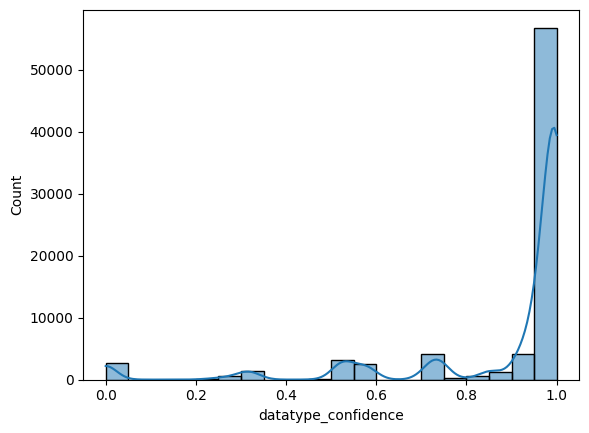

In [10]:
# df_all_best = df_all[df_all["datatype_confidence"] > 0.95]
# Plot datatype confidence distribution
sns.histplot(data=df_all, x="datatype_confidence", bins=20, kde=True)

In [ ]:
# Number of rows with min(datatype_confidence, suffix_confidence, is_derived_confidence) > threshold
threshold = 0.88

high_confidence_count = df_all[
    (df_all["datatype_confidence"] > threshold) &
    (df_all["suffix_confidence"] > threshold) &
    (df_all["derived_confidence"] > threshold)
].shape[0]
print(f"Number of rows with all confidences > {threshold}: {high_confidence_count} out of {df_all.shape[0]} total rows ({high_confidence_count / df_all.shape[0] * 100:.2f}%)")

Number of rows with all confidences > 0.88: 2674 out of 45356 total rows (5.90%)


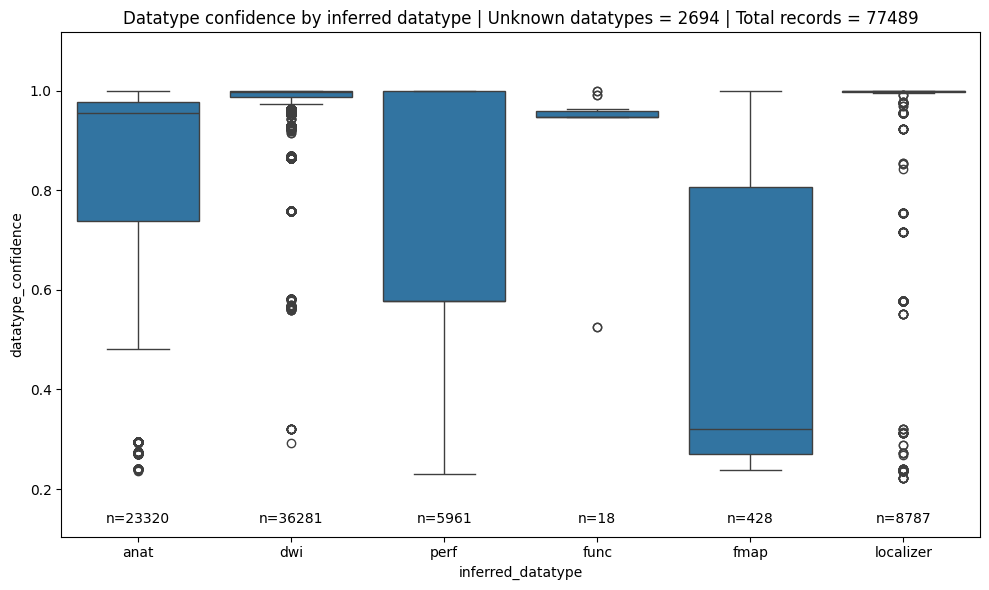

In [11]:
# Per datatype boxplot + annotation of number of records (n) for each datatype

unknown_datatype_count = (df_all["inferred_datatype"] == "unknown").sum()
n_records = df_all.shape[0]

datatypes = ["anat", "dwi", "perf", "func", "fmap", "localizer"]
plot_df = df_all[df_all["inferred_datatype"].isin(datatypes)].copy()

if plot_df.empty:
    raise ValueError("No rows found for selected datatypes.")

order = [d for d in datatypes if d in plot_df["inferred_datatype"].unique()]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=plot_df,
    x="inferred_datatype",
    y="datatype_confidence",
    order=order,
    ax=ax,
)

counts = plot_df["inferred_datatype"].value_counts().reindex(order, fill_value=0)

# Add headroom so top annotations are visible
ax.margins(y=0.15)

for i, datatype in enumerate(order):
    ax.text(
        i,
        0.02,  # Adjust this value to position the text higher or lower
        f"n={int(counts[datatype])}",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=10,
        clip_on=False,
    )

ax.set_title(f"Datatype confidence by inferred datatype | Unknown datatypes = {unknown_datatype_count} | Total records = {n_records}")
ax.set_xlabel("inferred_datatype")
ax.set_ylabel("datatype_confidence")
plt.tight_layout()
plt.show()

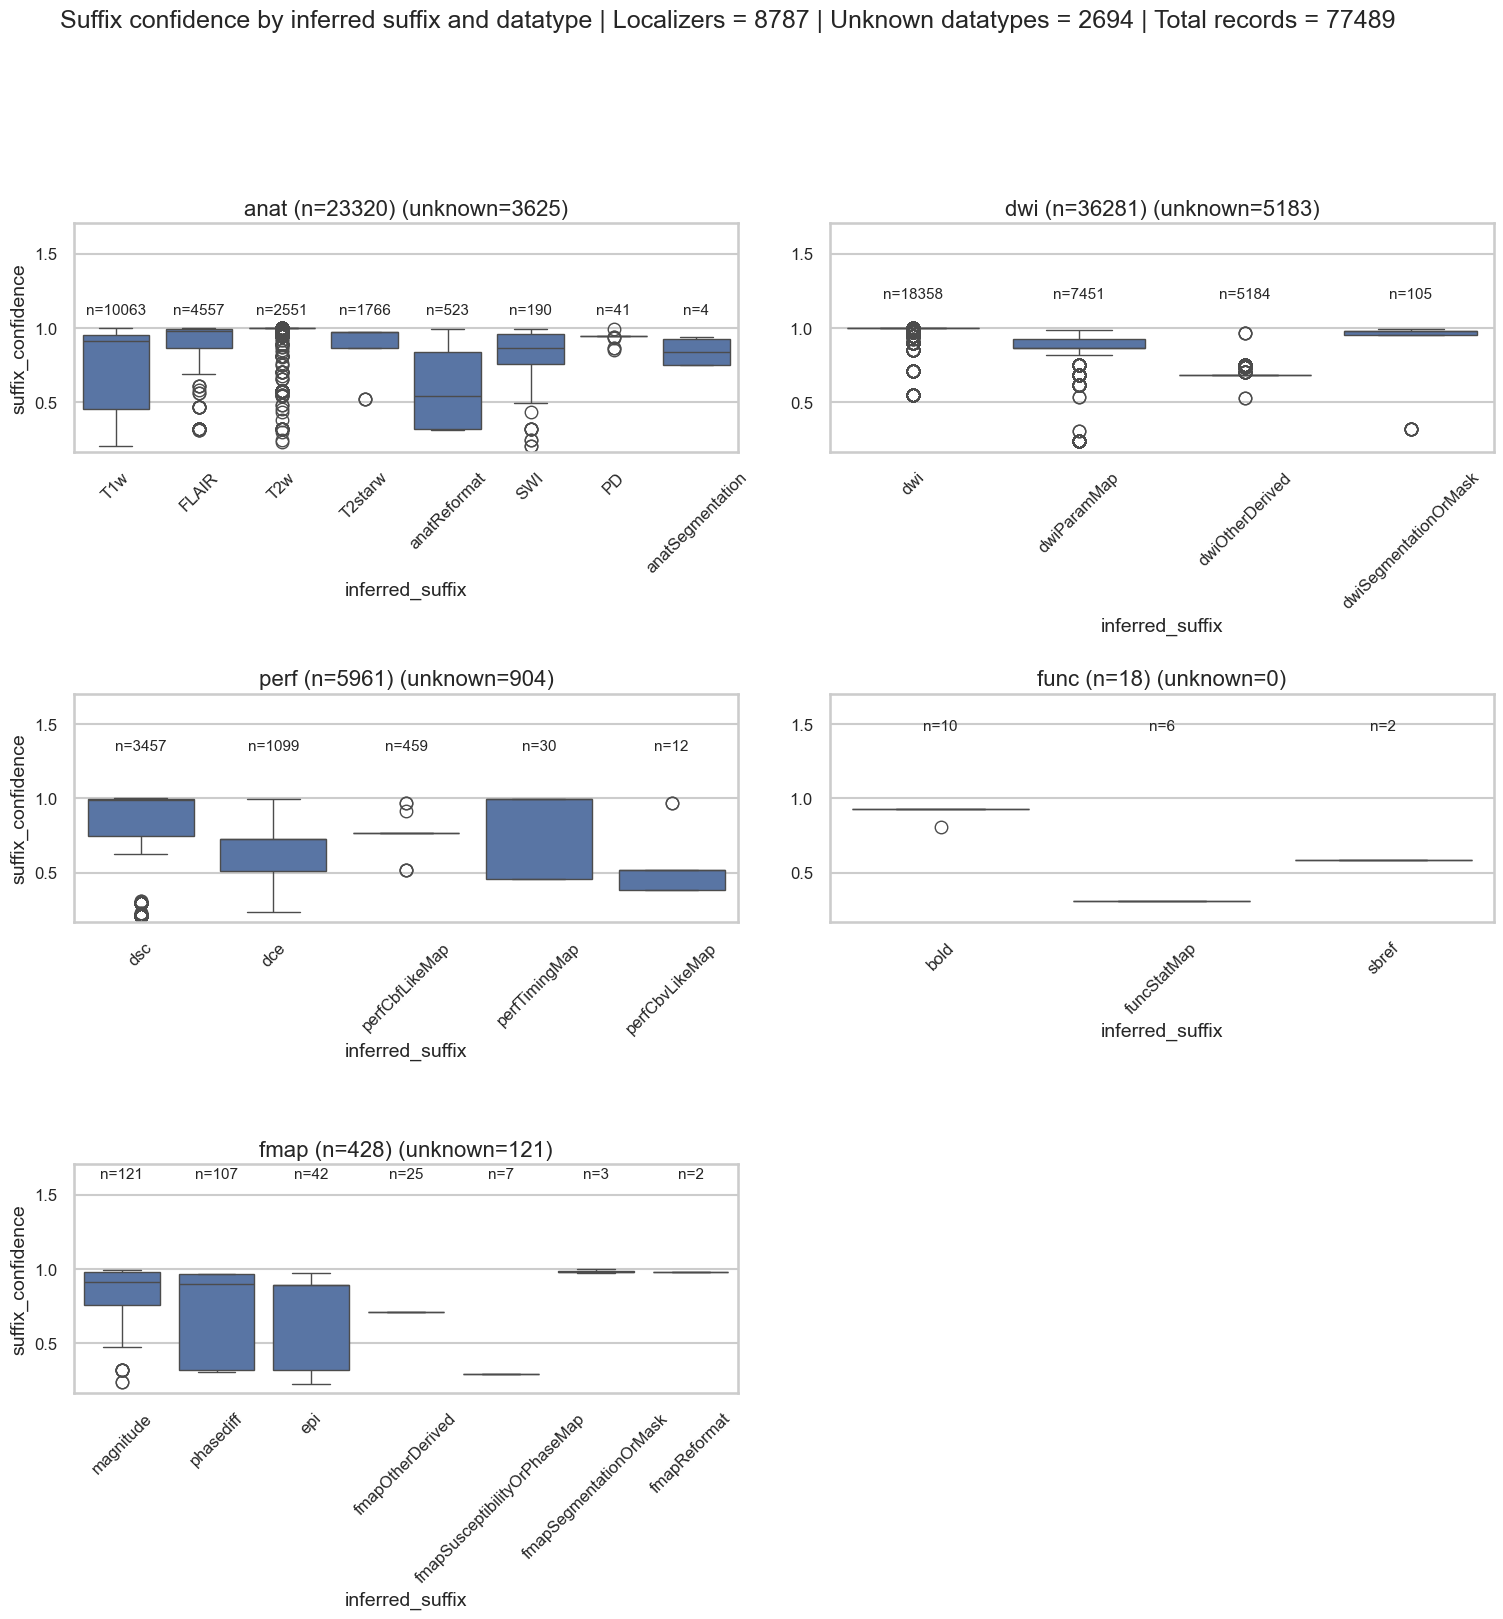

In [13]:
# Per suffix - plot distribution of suffix confidence for each datatype in a grid (presentation style)

sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=1.25)  # global font scaling for presentation

n_records = len(df_all.index)

localizer_count = (df_all["inferred_datatype"] == "localizer").sum()
unknown_datatype_count = (df_all["inferred_datatype"] == "unknown").sum()

datatypes = ["anat", "dwi", "perf", "func", "fmap"]
plot_df = df_all[df_all["inferred_datatype"].isin(datatypes)].copy()

n_cols = 2
n_rows = (len(datatypes) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5.5 * n_rows), sharey=True)
axes = axes.flatten()

for ax, datatype in zip(axes, datatypes):
    subset = plot_df[plot_df["inferred_datatype"] == datatype]

    if subset.empty:
        ax.set_title(f"{datatype} (no samples)", fontsize=16)
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, fontsize=14)
        ax.set_xticks([])
        ax.tick_params(axis="y", labelleft=True, labelsize=12)
        continue

    order = [s for s in subset["inferred_suffix"] if s != "unknown"]
    unknown_count_subset = (subset["inferred_suffix"] == "unknown").sum()
    order = pd.Series(order).value_counts().index.tolist()
    counts = subset["inferred_suffix"].value_counts().reindex(order)

    sns.boxplot(
        data=subset,
        x="inferred_suffix",
        y="suffix_confidence",
        order=order,
        ax=ax
    )

    ymin, ymax = ax.get_ylim()
    pad = max(0.04, (ymax - ymin) * 0.12)
    ax.set_ylim(ymin, ymax + pad)

    for i, (suffix, n) in enumerate(counts.items()):
        ax.text(i, ymax + pad * 0.30, f"n={n}", ha="center", va="bottom", fontsize=11)

    ax.set_title(f"{datatype} (n={len(subset)}) (unknown={unknown_count_subset})", fontsize=16)
    ax.set_xlabel("inferred_suffix", fontsize=14)
    ax.set_ylabel("suffix_confidence", fontsize=14)
    ax.tick_params(axis="x", rotation=45, labelsize=12)
    ax.tick_params(axis="y", labelleft=True, labelsize=12)

for ax in axes[len(datatypes):]:
    ax.axis("off")

fig.suptitle(
    f"Suffix confidence by inferred suffix and datatype | Localizers = {localizer_count} | Unknown datatypes = {unknown_datatype_count} | Total records = {n_records}",
    fontsize=18,
    y=1.02
)
fig.tight_layout(rect=[0.03, 0.03, 1, 0.96])  # type: ignore
plt.show()

In [ ]:
specific_features = proactive_dataset.search_series_by_id(
    subject_id="2182-1343",
    session_id="2182-1343-2256-7194",
    series_id="15",
)
specific_features

NameError: name 'proactive_dataset' is not defined